Data Loading and Preprocessing


We will use the Hugging Face IMDB movie review dataset for RNN based sentiment analysis.


In [1]:
!uv pip install datasets matplotlib


Using Python 3.12.12 environment at: /usr
Audited 2 packages in 349ms


In [15]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset


In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_VOCAB = 20000
MAX_LEN = 400
BATCH_SIZE = 64
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3

print(f"Device: {DEVICE}")


Device: cuda


In [17]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"\b\w+\b", text)


def load_imdb():
    print("Downloading/Loading Hugging Face IMDB dataset...")
    dataset = load_dataset("imdb")
    train_texts = dataset["train"]["text"]
    train_labels = dataset["train"]["label"]
    test_texts = dataset["test"]["text"]
    test_labels = dataset["test"]["label"]
    return train_texts, train_labels, test_texts, test_labels


In [5]:
train_texts, train_labels, test_texts, test_labels = load_imdb()
print(f"Train samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(train_texts[0][:500])


Downloading/Loading Hugging Face IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples: 25000
Test samples: 25000
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent


In [6]:
def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        word2idx[word] = len(word2idx)
    return word2idx


def encode(text, word2idx, max_len=MAX_LEN):
    tokens = tokenize(text)[:max_len]
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]


In [7]:
word2idx = build_vocab(train_texts, MAX_VOCAB)
vocab_size = len(word2idx)
print(f"Vocab size: {vocab_size}")


Vocab size: 20000


We use token indexing, sequence length truncation, and dynamic padding to construct minibatches for the RNN model.


In [18]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode(self.texts[idx], self.word2idx)
        if not encoded:
            encoded = [self.word2idx["<UNK>"]]
        return encoded, self.labels[idx]


def collate_fn(batch):
    sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, lengths, labels


In [19]:
train_ds = IMDBDataset(train_texts, train_labels, word2idx)
test_ds = IMDBDataset(test_texts, test_labels, word2idx)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    pin_memory=True,
)


Model training


In [20]:
class SentimentRNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=2,
        dropout=DROPOUT,
    ):
        super().__init__()
        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=rnn_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden))


Training


In [21]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, lengths, y in loader:
        x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
        logits = model(x, lengths)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def predict_text(model, text, word2idx):
    model.eval()
    ids = encode(text, word2idx)
    if not ids:
        ids = [word2idx["<UNK>"]]
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(DEVICE)
    logits = model(x, lengths)
    return logits.argmax(dim=1).item()


In [27]:
model = SentimentRNN(vocab_size).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 6
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
        f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}"
    )


Epoch 1/6  train_loss=0.6871  train_acc=0.5518  test_loss=0.6687  test_acc=0.5822
Epoch 2/6  train_loss=0.6284  train_acc=0.6456  test_loss=0.5686  test_acc=0.7202
Epoch 3/6  train_loss=0.5529  train_acc=0.7276  test_loss=0.5582  test_acc=0.7232
Epoch 4/6  train_loss=0.5287  train_acc=0.7474  test_loss=0.5504  test_acc=0.7195
Epoch 5/6  train_loss=0.4937  train_acc=0.7733  test_loss=0.5745  test_acc=0.7278
Epoch 6/6  train_loss=0.4546  train_acc=0.7995  test_loss=0.5609  test_acc=0.7424


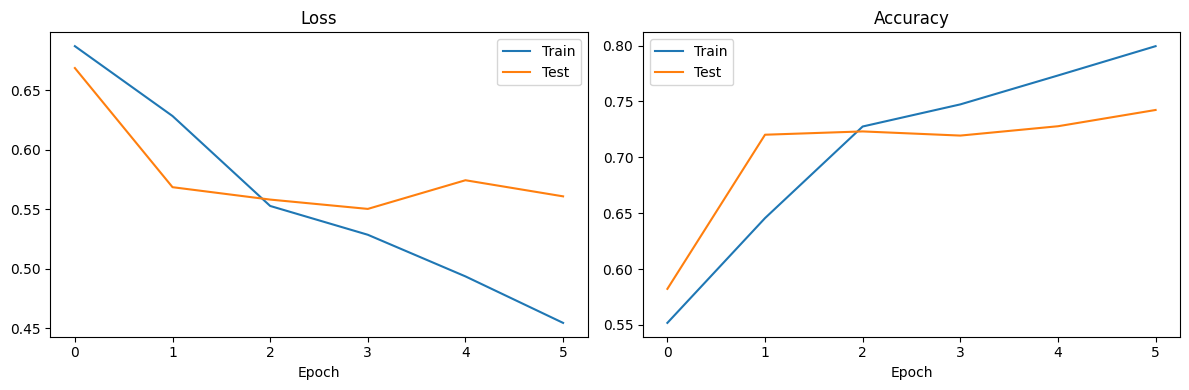

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [29]:
label_map = {0: "negative", 1: "positive"}
samples = test_texts[:10]
sample_labels = test_labels[:10]
predictions = [predict_text(model, text, word2idx) for text in samples]

print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}\n")
for i, (text, true_label, pred_label) in enumerate(
    zip(samples, sample_labels, predictions), start=1
):
    print(f"--- Sample {i} ---")
    print(f"Text: {text[:200]}...")
    print(f"True: {label_map[true_label]}  |  Predicted: {label_map[pred_label]}\n")


Final Test Accuracy: 0.7424

--- Sample 1 ---
Text: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab...
True: negative  |  Predicted: negative

--- Sample 2 ---
Text: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell ...
True: negative  |  Predicted: negative

--- Sample 3 ---
Text: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s...
True: negative  |  Predicted: negative

--- Sample 4 ---
Text: STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop

RNN tends to show worse performance than 1D CNN likely due to the vanishing gradient problem and the relatively small dataset size, max pooling also provides an inductive bias that helps the 1D CNN lean better.
